# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-21 15:48:00.761072: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 15:48:00.771644: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-21 15:48:00.915571: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-21 15:48:00.915665: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-21 15:48:00.915967: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/hanisbev/ai/projects/UCI HAR Dataset


## 3. Load the Data


In [3]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype = np.float32)#<--- Enter your code here --->#
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype = np.int32) - 1 #<--- Enter your code here --->#
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype = np.float32) #<--- Enter your code here --->#
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype = np.int32) - 1#<--- Enter your code here --->#

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [4]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [5]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation = "relu"),
        layers.Dense(256, activation = "relu"),
        layers.Dense(128, activation = "relu"),
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation = "relu"),
        layers.Dense(64, activation = "relu"),
        #<--- Enter your code here --->#,
        #<--- Enter your code here --->#,
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


2026-04-21 15:48:10.043151: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: UNKNOWN ERROR (100)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [6]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs = 20, batch_size = 64, callbacks = teacher_callbacks, verbose = 1)
    #<--- Enter your code here --->#


Epoch 1/20
115/115 [==============================] - 3s 20ms/step - loss: 0.3901 - accuracy: 0.8399 - val_loss: 0.3634 - val_accuracy: 0.8341
Epoch 2/20
115/115 [==============================] - 1s 7ms/step - loss: 0.1400 - accuracy: 0.9452 - val_loss: 0.2410 - val_accuracy: 0.9162
Epoch 3/20
115/115 [==============================] - 2s 19ms/step - loss: 0.0974 - accuracy: 0.9623 - val_loss: 0.1624 - val_accuracy: 0.9410
Epoch 4/20
115/115 [==============================] - 2s 18ms/step - loss: 0.0928 - accuracy: 0.9625 - val_loss: 0.2119 - val_accuracy: 0.9206
Epoch 5/20
115/115 [==============================] - 2s 18ms/step - loss: 0.0800 - accuracy: 0.9690 - val_loss: 0.2154 - val_accuracy: 0.9243
Epoch 6/20
115/115 [==============================] - 2s 18ms/step - loss: 0.0713 - accuracy: 0.9729 - val_loss: 0.1746 - val_accuracy: 0.9403


### Teacher Training Curves


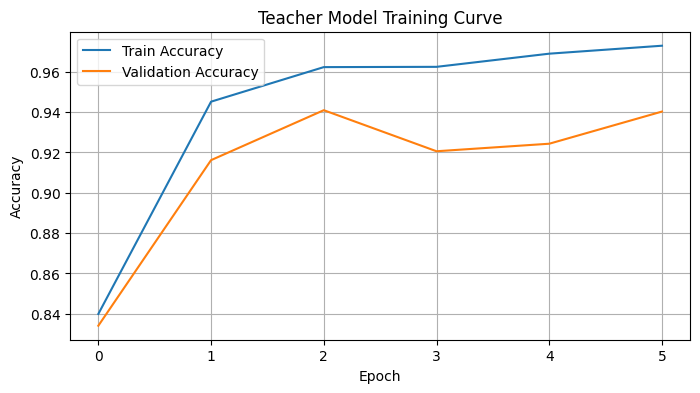

In [7]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [8]:
teacher_probs = teacher_model.predict(X_test, verbose=0)
teacher_preds = np.argmax(teacher_probs, axis=1)
teacher_acc = accuracy_score(y_test, teacher_preds)

print(f"Teacher Test Accuracy: {teacher_acc:.4f}\n")
print(classification_report(y_test, teacher_preds, target_names=class_names, digits=4))

Teacher Test Accuracy: 0.9410

                    precision    recall  f1-score   support

           WALKING     0.8851    0.9940    0.9364       496
  WALKING_UPSTAIRS     0.9632    0.8344    0.8942       471
WALKING_DOWNSTAIRS     0.9456    0.9524    0.9490       420
           SITTING     0.9320    0.9206    0.9262       491
          STANDING     0.9275    0.9380    0.9327       532
            LAYING     1.0000    0.9981    0.9991       537

          accuracy                         0.9410      2947
         macro avg     0.9422    0.9396    0.9396      2947
      weighted avg     0.9426    0.9410    0.9405      2947



## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 6ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.2443 - val_accuracy: 0.9103
Epoch 2/20
92/92 [==============================] - 1s 8ms/step - loss: 0.1845 - accuracy: 0.9345 - val_loss: 0.1950 - val_accuracy: 0.9177
Epoch 3/20
92/92 [==============================] - 1s 8ms/step - loss: 0.1514 - accuracy: 0.9415 - val_loss: 0.2699 - val_accuracy: 0.9123
Epoch 4/20
92/92 [==============================] - 1s 7ms/step - loss: 0.1158 - accuracy: 0.9565 - val_loss: 0.1503 - val_accuracy: 0.9347
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - loss: 0.0891 - accuracy: 0.9663 - val_loss: 0.1711 - val_accuracy: 0.9252
Epoch 6/20
92/92 [==============================] - 1s 7ms/step - loss: 0.0669 - accuracy: 0.9779 - val_loss: 0.2556 - val_accuracy: 0.9184
Epoch 7/20
92/92 [==============================] - 1s 7ms/step - loss: 0.0642 - accuracy: 0.9765 - val_loss: 0.1501 - val_accuracy: 0.9381
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


In [10]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training = False)#<--- Enter your code here --->#

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training = True) #<--- Enter your code here --->#

            student_loss = self.student_loss_fn( y, student_predictions)#<--- Enter your code here --->#

            temperature  = self.temperature 
            teacher_soft = tf.nn.softmax(teacher_predictions / temperature)
            student_soft = tf.nn.softmax(student_predictions / temperature)
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft) * (temperature ** 2) #<--- Enter your code here --->#

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss #<--- Enter your code here --->#

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [11]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=64, callbacks = distillation_callbacks, verbose = 1)


Epoch 1/20
115/115 [==============================] - 2s 11ms/step - accuracy: 0.8198 - student_loss: 0.4829 - distillation_loss: 0.0193 - val_accuracy: 0.8463 - val_student_loss: 1.0291
Epoch 2/20
115/115 [==============================] - 1s 11ms/step - accuracy: 0.9396 - student_loss: 0.1660 - distillation_loss: 0.0043 - val_accuracy: 0.9294 - val_student_loss: 0.2780
Epoch 3/20
115/115 [==============================] - 1s 12ms/step - accuracy: 0.9584 - student_loss: 0.1168 - distillation_loss: 0.0026 - val_accuracy: 0.9416 - val_student_loss: 0.4504
Epoch 4/20
115/115 [==============================] - 1s 11ms/step - accuracy: 0.9671 - student_loss: 0.0910 - distillation_loss: 0.0013 - val_accuracy: 0.9270 - val_student_loss: 0.1257
Epoch 5/20
115/115 [==============================] - 1s 11ms/step - accuracy: 0.9650 - student_loss: 0.0881 - distillation_loss: 0.0018 - val_accuracy: 0.9393 - val_student_loss: 0.2597
Epoch 6/20
115/115 [==============================] - 1s 12ms/ste

## 11. Train the Distilled Student


In [12]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 2s 10ms/step - accuracy: 0.7677 - student_loss: 0.6059 - distillation_loss: 0.0258 - val_accuracy: 0.9130 - val_student_loss: 0.0699
Epoch 2/20
92/92 [==============================] - 1s 11ms/step - accuracy: 0.9218 - student_loss: 0.2107 - distillation_loss: 0.0067 - val_accuracy: 0.9239 - val_student_loss: 0.0155
Epoch 3/20
92/92 [==============================] - 1s 11ms/step - accuracy: 0.9412 - student_loss: 0.1536 - distillation_loss: 0.0042 - val_accuracy: 0.9184 - val_student_loss: 0.0106
Epoch 4/20
92/92 [==============================] - 1s 11ms/step - accuracy: 0.9589 - student_loss: 0.1147 - distillation_loss: 0.0026 - val_accuracy: 0.9368 - val_student_loss: 0.0074
Epoch 5/20
92/92 [==============================] - 1s 11ms/step - accuracy: 0.9694 - student_loss: 0.0874 - distillation_loss: 0.0015 - val_accuracy: 0.9293 - val_student_loss: 0.0014
Epoch 6/20
92/92 [==============================] - 1s 11ms/step - accuracy

### Distillation Training Curves


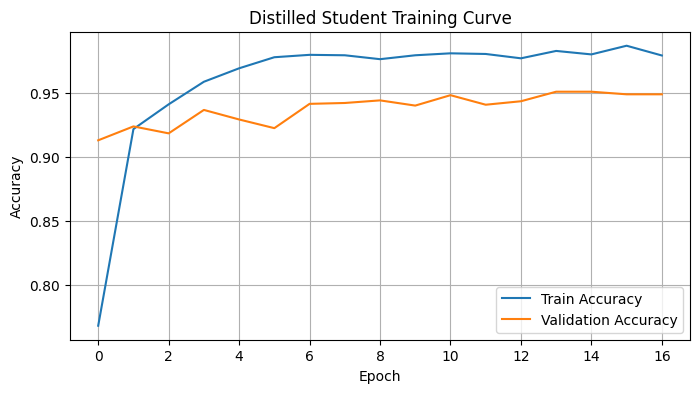

In [13]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9318

                    precision    recall  f1-score   support

           WALKING     0.9327    0.9778    0.9547       496
  WALKING_UPSTAIRS     0.9413    0.9193    0.9302       471
WALKING_DOWNSTAIRS     0.9537    0.9310    0.9422       420
           SITTING     0.8936    0.9063    0.8999       491
          STANDING     0.8771    0.8985    0.8877       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9318      2947
         macro avg     0.9330    0.9317    0.9321      2947
      weighted avg     0.9328    0.9318    0.9320      2947



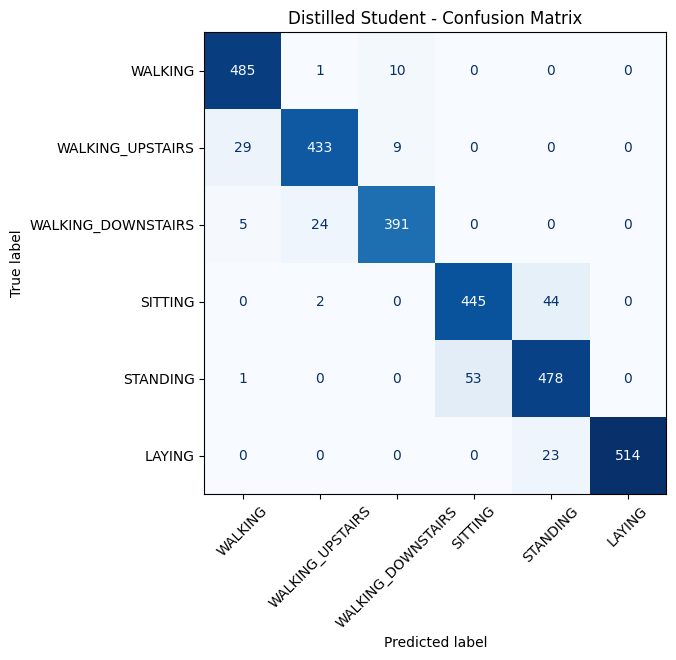

In [14]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [15]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8) #<--- Enter your code here --->#
        elif input_details["dtype"] == np.uint8:
            x = (x / input_scale + input_zero_point).astype(np.uint8)#<--- Enter your code here --->#
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale #<--- Enter your code here --->#
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale  #<--- Enter your code here --->#

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(100):
        yield [X_train[i: i +1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [16]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [17]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)#<--- Enter your code here --->#

student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params) #<--- Enter your code here --->#

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(X_train, y_train, validation_split = 0.2, epochs = pruning_epochs, batch_size = batch_size, callbacks = pruning_callbacks, verbose = 1)

Epoch 1/10
92/92 [==============================] - 2s 10ms/step - loss: 0.0342 - accuracy: 0.9888 - val_loss: 0.1388 - val_accuracy: 0.9483
Epoch 2/10
92/92 [==============================] - 1s 8ms/step - loss: 0.0372 - accuracy: 0.9878 - val_loss: 0.1276 - val_accuracy: 0.9524
Epoch 3/10
92/92 [==============================] - 1s 8ms/step - loss: 0.0616 - accuracy: 0.9825 - val_loss: 0.1089 - val_accuracy: 0.9585
Epoch 4/10
92/92 [==============================] - 1s 8ms/step - loss: 0.0813 - accuracy: 0.9764 - val_loss: 0.1157 - val_accuracy: 0.9565
Epoch 5/10
92/92 [==============================] - 1s 8ms/step - loss: 0.2049 - accuracy: 0.9429 - val_loss: 0.1288 - val_accuracy: 0.9619
Epoch 6/10
92/92 [==============================] - 1s 9ms/step - loss: 1.0352 - accuracy: 0.7339 - val_loss: 0.7439 - val_accuracy: 0.6621
Epoch 7/10
92/92 [==============================] - 1s 9ms/step - loss: 1.3233 - accuracy: 0.6251 - val_loss: 1.3913 - val_accuracy: 0.5493
Epoch 8/10
92/92 [=

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [18]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)#<--- Enter your code here --->#
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)#<--- Enter your code here --->#

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpft0825fk/assets


INFO:tensorflow:Assets written to: /tmp/tmpft0825fk/assets
2026-04-21 15:49:23.161642: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 15:49:23.161710: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 15:49:23.162255: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpft0825fk
2026-04-21 15:49:23.166134: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 15:49:23.166169: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpft0825fk
2026-04-21 15:49:23.178351: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-21 15:49:23.180410: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 15:49:23.263155: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpf4fpzn39/assets


INFO:tensorflow:Assets written to: /tmp/tmpf4fpzn39/assets
2026-04-21 15:49:24.147276: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 15:49:24.147343: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 15:49:24.147520: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpf4fpzn39


Pruned distilled model with mask accuracy: 0.9345
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9345
Stripped sparse distilled model size (KB): 127.98


2026-04-21 15:49:24.148296: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 15:49:24.148315: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpf4fpzn39
2026-04-21 15:49:24.150073: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 15:49:24.167703: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpf4fpzn39
2026-04-21 15:49:24.177769: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 30247 microseconds.


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [19]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]#<--- Enter your code here --->#
converter.representative_dataset = representative_data_gen #<--- Enter your code here --->#
converter.target_spec.supported_ops =  [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]#<--- Enter your code here --->#
converter.inference_input_type = tf.int8 #<--- Enter your code here --->#
converter.inference_output_type = tf.int8 #<--- Enter your code here --->#

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpieu6yiqv/assets


INFO:tensorflow:Assets written to: /tmp/tmpieu6yiqv/assets
/home/hanisbev/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Stripped Sparse + INT8 Accuracy: 0.9335
Stripped Sparse + INT8 Size (KB): 81.78


2026-04-21 15:49:24.736500: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 15:49:24.736561: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 15:49:24.736757: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpieu6yiqv
2026-04-21 15:49:24.737302: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 15:49:24.737313: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpieu6yiqv
2026-04-21 15:49:24.738755: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 15:49:24.756272: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpieu6yiqv
2026-04-21 15:49:24.763370: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 26611 m

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [20]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp1lxzjt9s/assets


INFO:tensorflow:Assets written to: /tmp/tmp1lxzjt9s/assets
/home/hanisbev/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Stripped Sparse + INT8 Accuracy: 0.9335
Stripped Sparse + INT8 Size (KB): 65.53


2026-04-21 15:49:25.318861: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 15:49:25.318931: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 15:49:25.319131: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1lxzjt9s
2026-04-21 15:49:25.319853: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 15:49:25.319870: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1lxzjt9s
2026-04-21 15:49:25.321619: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 15:49:25.341100: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1lxzjt9s
2026-04-21 15:49:25.349263: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 30129 m

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [21]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)

distilled_fp32_size_kb = save_binary_model(
    distilled_fp32_tflite,
    "distilled_fp32.tflite"
)

distilled_fp32_acc, _ = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

INFO:tensorflow:Assets written to: /tmp/tmpshpblu1g/assets


INFO:tensorflow:Assets written to: /tmp/tmpshpblu1g/assets
2026-04-21 15:49:25.914930: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 15:49:25.915014: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 15:49:25.915215: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpshpblu1g
2026-04-21 15:49:25.915889: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 15:49:25.915904: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpshpblu1g
2026-04-21 15:49:25.917529: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 15:49:25.935086: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpshpblu1g
2026-04-21 15:49:25.942293: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

In [22]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.931795,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.934510,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.934510,127.984375
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.933492,65.531250


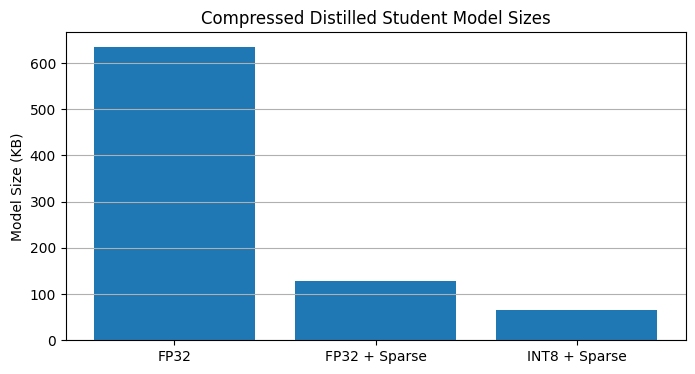

In [23]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


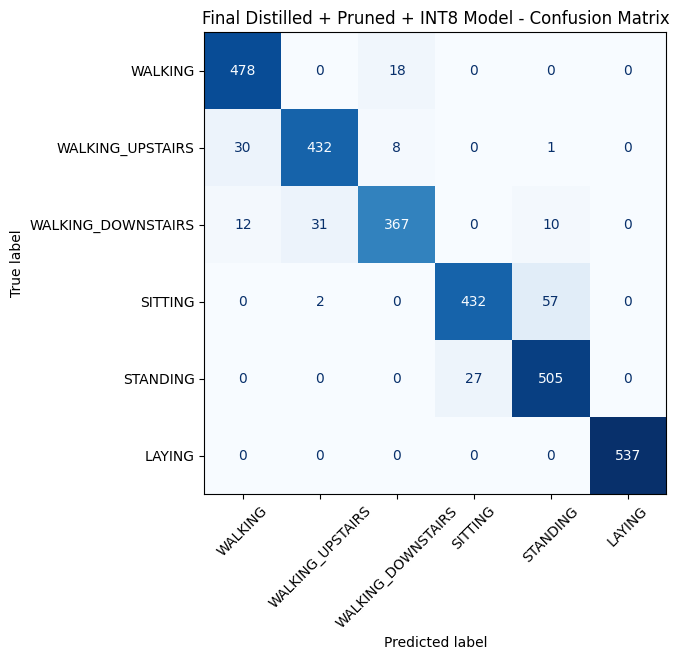

In [24]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**? The baseline student and distilled student achieved similar test accuracy, but the distilled student trained more stable and generalized slightly better. 
2. Did **knowledge distillation** help the smaller model retain performance? Yes, despite being smaller than the teacher, the distilled student was similar to the teacher-level accuracy. This shows that soft labels transferred the teachers learned represenations to the smaller model without requiring the student to learn everything from scratch.
3. What happened to the model size after **pruning** and after **INT8 quantization**? Pruning reduced the model size by exploiting the weight sparsity with the sparse optimization flag. INT8 quantization reduced it further by replacing 32-bit floats with 8-bit integers. This caused roughly a 5x compression over the baseline model. 
4. Which model would you choose for **Arduino deployment**, and why? I would chose the sparse INT8 model. Since Arduino boards have limited flash memory and no floating point unit, the smallest model that maintains a good accuracy is best. 
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate? It is a good candidate because it has all the TinyML requirements like small size, doesnt need an FPU, and a high sparsity and accuracy. The combination of knowledge distillation, pruning, and quantization are best for TinyML.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
